# RF Signal Processing for Beam Arrival Monitors (BAM)

This notebook walks through the key signal-processing blocks used in a
**Beam Arrival Monitor** (BAM) at a particle-accelerator facility.
Each section contains:

1. The minimal governing equations
2. A Python simulation cell
3. One or more plots
4. A parameter-sweep "what changes and why" cell

Sections
--------
0. Imports & global configuration  
1. Baseline – damped RF signal and IQ phase estimation  
2. Band-pass filtering  
3. RF mixer  
4. IQ demodulation  
5. Local oscillator effects (phase noise, frequency offset)  
6. PLL behaviour  
7. ADC sampling (Nyquist, aliasing, quantisation, jitter)  
8. Digital phase detection (unwrapping, windowed averaging)  
9. Calibration with a timing scan  
10. End-to-end BAM-like chain  
11. Final validation – timing resolution and operating range


## 0. Imports & Global Configuration

In [3]:
# Optional: ensure NumPy is available in the notebook environment
%pip install -q numpy matplotlib scipy


Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from scipy.stats import linregress

# ── Global parameters (edit here to explore different conditions) ─────────────
FS          = 200e6        # Sample rate [Hz]
FC          = 20e6         # RF / carrier frequency [Hz]
DURATION    = 10e-6        # Signal window length [s]
TAU         = 2e-6         # Exponential decay time-constant [s]

PHI_RF      = np.deg2rad(35.0)   # RF initial phase [rad]
PHI_LO      = 0.0                # LO initial phase [rad]

BPF_BW      = 4e6          # Bandpass filter 3-dB bandwidth [Hz]
LPF_CUT     = 2e6          # I/Q low-pass cut-off [Hz]
ADC_BITS    = 12           # ADC word length [bits]
JITTER_RMS_S = 5e-12       # ADC clock jitter rms [s]

# Derived
dt = 1.0 / FS
t  = np.arange(int(DURATION * FS)) * dt
N  = len(t)

print(f"N = {N} samples,  dt = {dt*1e9:.2f} ns,  Nyquist = {FS/2/1e6:.0f} MHz")
print(f"RF freq = {FC/1e6:.0f} MHz,  damping τ = {TAU*1e6:.1f} µs")


N = 2000 samples,  dt = 5.00 ns,  Nyquist = 100 MHz
RF freq = 20 MHz,  damping τ = 2.0 µs


## 1. Baseline: Damped RF Signal and IQ Phase Estimation

The RF signal from a BAM cavity is modelled as an exponentially damped cosine:

$$s(t) = e^{-t/\tau} \cos(2\pi f_c t + \phi_{RF})$$

IQ demodulation mixes $s(t)$ with a local oscillator (LO) at the same frequency,
then low-pass filters to isolate the baseband components:

$$I(t) = \mathrm{LP}\!\left[2\,s(t)\cos(2\pi f_c t + \phi_{LO})\right]
        = e^{-t/\tau}\cos(\phi_{RF}-\phi_{LO})$$

$$Q(t) = \mathrm{LP}\!\left[-2\,s(t)\sin(2\pi f_c t + \phi_{LO})\right]
       = e^{-t/\tau}\sin(\phi_{RF}-\phi_{LO})$$

The phase difference is recovered via:

$$\hat{\phi} = \arctan2(Q,\, I) = \phi_{RF} - \phi_{LO}$$


Actual phase difference : 35.0000 deg
Estimated               : 34.9942 deg
Error                   : -5.761 mdeg


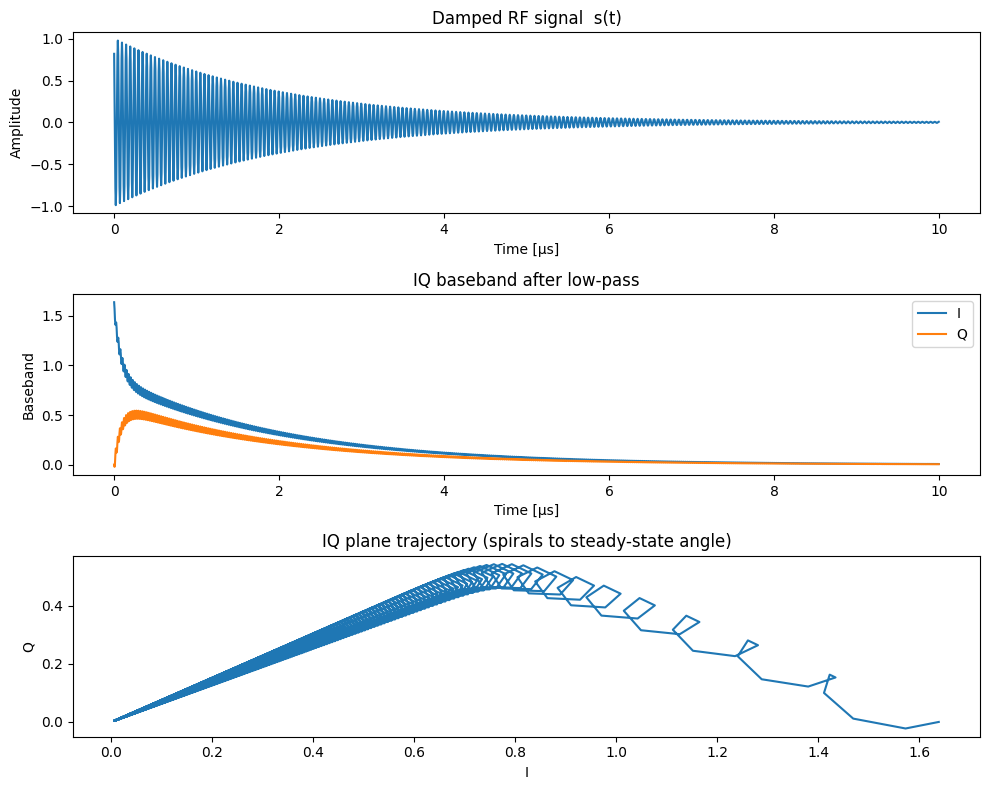

In [5]:
import sys
# Jupyter sets CWD to the notebook directory; "." puts signal_eval on the path.
if "." not in sys.path:
    sys.path.insert(0, ".")

from signal_eval import SimulationConfig, run_simulation, lowpass_ema

cfg = SimulationConfig(
    duration_s=DURATION, sample_rate_hz=FS,
    rf_freq_hz=FC, ref_freq_hz=FC,
    damping_tau_s=TAU,
    rf_phase_rad=PHI_RF, ref_phase_rad=PHI_LO,
    lowpass_cutoff_hz=LPF_CUT,
)
res = run_simulation(cfg)

actual = float(np.arctan2(np.sin(PHI_RF - PHI_LO), np.cos(PHI_RF - PHI_LO)))
est    = float(res["estimated_phase_rad"])
print(f"Actual phase difference : {np.rad2deg(actual):.4f} deg")
print(f"Estimated               : {np.rad2deg(est):.4f} deg")
print(f"Error                   : {np.rad2deg(est - actual)*1e3:.3f} mdeg")

t_us = res["t"] * 1e6
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
axes[0].plot(t_us, res["rf_signal"])
axes[0].set(xlabel="Time [µs]", ylabel="Amplitude", title="Damped RF signal  s(t)")
axes[1].plot(t_us, res["i_baseband"], label="I")
axes[1].plot(t_us, res["q_baseband"], label="Q")
axes[1].set(xlabel="Time [µs]", ylabel="Baseband", title="IQ baseband after low-pass")
axes[1].legend()
axes[2].plot(res["i_baseband"], res["q_baseband"])
axes[2].set(xlabel="I", ylabel="Q", title="IQ plane trajectory (spirals to steady-state angle)")
plt.tight_layout()
plt.show()


## 2. Band-Pass Filtering

A band-pass filter (BPF) centred at $f_c$ with 3-dB bandwidth $B$ selects the RF
signal and rejects out-of-band noise and interferers.

A 4th-order Butterworth BPF with passband $[f_c - B/2,\; f_c + B/2]$:

$$|H(j\omega)|^2 = \frac{1}{1+\left(\dfrac{\omega^2-\omega_c^2}{B\,\omega}\right)^{2n}}$$

**Key trade-off:**
| Narrow BW | Wide BW |
|-----------|---------|
| High noise rejection | Passes more noise |
| Long impulse response → ringing / slow settling | Fast settling |


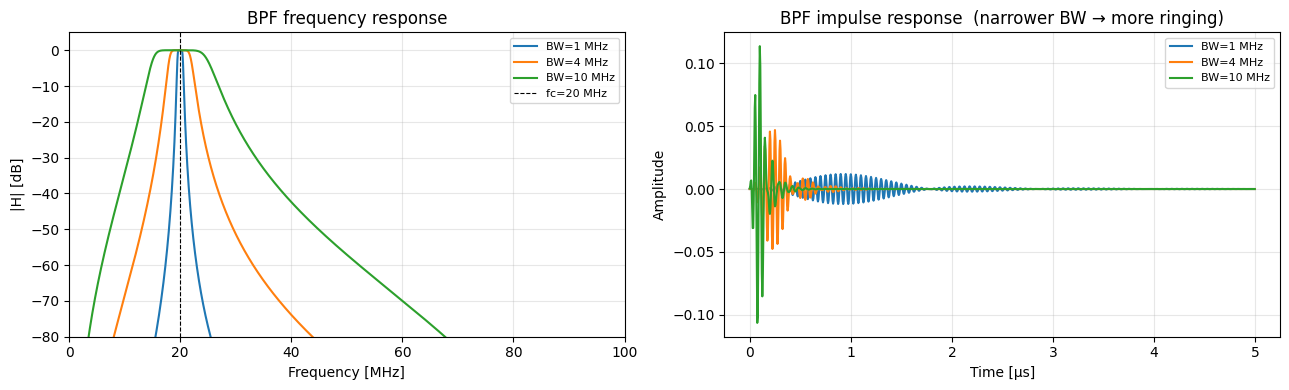

In [6]:
def make_bpf(fc_hz, bw_hz, fs_hz, order=4):
    """Butterworth bandpass filter as second-order-sections (SOS)."""
    nyq  = fs_hz / 2.0
    lo   = (fc_hz - bw_hz / 2.0) / nyq
    hi   = (fc_hz + bw_hz / 2.0) / nyq
    lo   = float(np.clip(lo, 1e-4, 0.9998))
    hi   = float(np.clip(hi, lo + 1e-4, 0.9999))
    return sp_signal.butter(order, [lo, hi], btype="band", output="sos")

bws   = [1e6, 4e6, 10e6]
freqs = np.linspace(0, FS / 2, 4096)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for bw in bws:
    sos = make_bpf(FC, bw, FS)
    w, h = sp_signal.sosfreqz(sos, worN=freqs, fs=FS)
    axes[0].plot(w / 1e6, 20 * np.log10(np.abs(h) + 1e-12), label=f"BW={bw/1e6:.0f} MHz")

axes[0].axvline(FC / 1e6, color="k", ls="--", lw=0.8, label=f"fc={FC/1e6:.0f} MHz")
axes[0].set(xlabel="Frequency [MHz]", ylabel="|H| [dB]",
            title="BPF frequency response", ylim=[-80, 5], xlim=[0, FS / 2e6])
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

imp = np.zeros(1000); imp[0] = 1.0
for bw in bws:
    sos = make_bpf(FC, bw, FS)
    y   = sp_signal.sosfilt(sos, imp)
    axes[1].plot(np.arange(1000) * dt * 1e6, y, label=f"BW={bw/1e6:.0f} MHz")

axes[1].set(xlabel="Time [µs]", ylabel="Amplitude",
            title="BPF impulse response  (narrower BW → more ringing)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


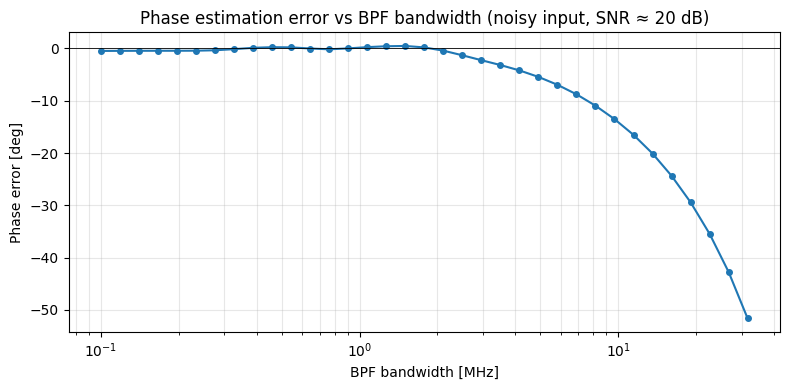

Narrow BW rejects noise → small error.  Very wide BW admits noise → error grows.


In [7]:
# Parameter sweep: phase-estimation error vs BPF bandwidth on a noisy RF signal
rng0 = np.random.default_rng(0)
rf_noisy = res["rf_signal"] + 0.05 * rng0.normal(size=N)

bw_sweep       = np.logspace(5, 7.5, 35)   # 100 kHz … ~30 MHz
phase_err_bw   = []

for bw in bw_sweep:
    try:
        sos      = make_bpf(FC, bw, FS)
        filtered = sp_signal.sosfilt(sos, rf_noisy)
    except Exception:
        phase_err_bw.append(np.nan); continue

    I_b = lowpass_ema(filtered * 2 * np.cos(2 * np.pi * FC * t),        FS, LPF_CUT)
    Q_b = lowpass_ema(filtered * (-2) * np.sin(2 * np.pi * FC * t),     FS, LPF_CUT)
    ph  = float(np.arctan2(np.mean(Q_b[N // 2:]), np.mean(I_b[N // 2:])))
    phase_err_bw.append(np.rad2deg(ph - actual))

plt.figure(figsize=(8, 4))
plt.semilogx(bw_sweep / 1e6, phase_err_bw, "o-", ms=4)
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("BPF bandwidth [MHz]")
plt.ylabel("Phase error [deg]")
plt.title("Phase estimation error vs BPF bandwidth (noisy input, SNR ≈ 20 dB)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()
print("Narrow BW rejects noise → small error.  Very wide BW admits noise → error grows.")


## 3. RF Mixer

A mixer is a multiplier.  By the product-to-sum identity:

$$\cos(\omega_1 t + \phi_1)\cdot\cos(\omega_2 t + \phi_2)
  = \tfrac{1}{2}\cos\!\bigl((\omega_1-\omega_2)t+(\phi_1-\phi_2)\bigr)
  + \tfrac{1}{2}\cos\!\bigl((\omega_1+\omega_2)t+(\phi_1+\phi_2)\bigr)$$

The **difference** term at $f_{IF} = f_1 - f_2$ carries the phase information.  
The **sum** term at $f_1 + f_2$ is removed by the subsequent low-pass filter.


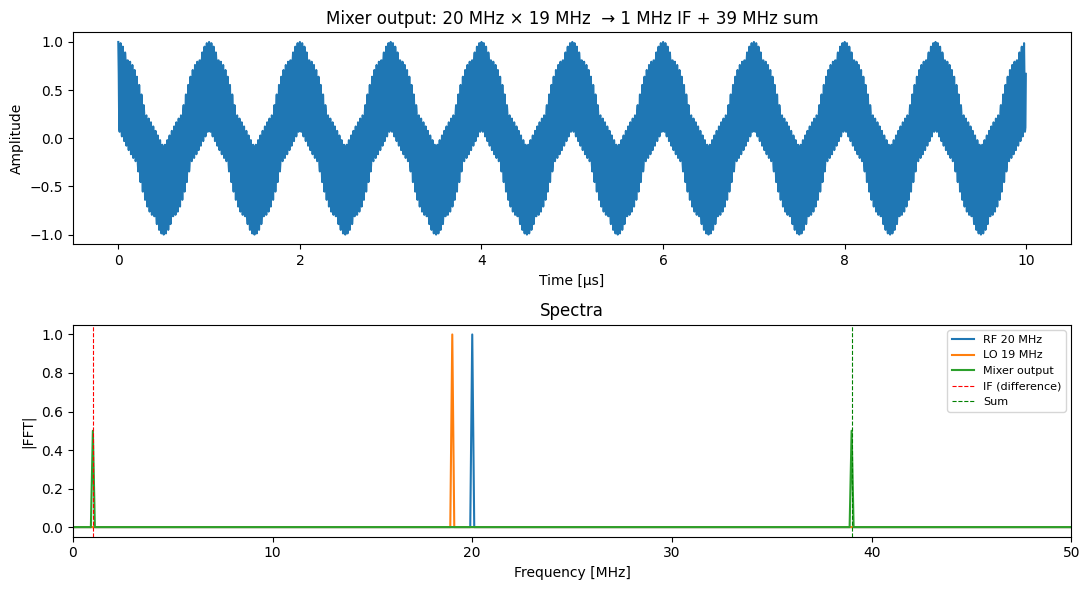

In [8]:
f_rf_mix = 20e6   # RF tone [Hz]
f_lo_mix = 19e6   # LO tone  (1 MHz offset → 1 MHz IF)

s_rf  = np.cos(2 * np.pi * f_rf_mix * t)
s_lo  = np.cos(2 * np.pi * f_lo_mix * t)
mixed = s_rf * s_lo

freq_ax = np.fft.rfftfreq(N, d=dt)
S_rf    = np.abs(np.fft.rfft(s_rf))  / N * 2
S_lo    = np.abs(np.fft.rfft(s_lo))  / N * 2
S_mix   = np.abs(np.fft.rfft(mixed)) / N * 2

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(t * 1e6, mixed)
axes[0].set(xlabel="Time [µs]", ylabel="Amplitude",
            title=f"Mixer output: {f_rf_mix/1e6:.0f} MHz × {f_lo_mix/1e6:.0f} MHz  "
                  f"→ {abs(f_rf_mix-f_lo_mix)/1e6:.0f} MHz IF + {(f_rf_mix+f_lo_mix)/1e6:.0f} MHz sum")

for spec, label in [(S_rf, f"RF {f_rf_mix/1e6:.0f} MHz"),
                    (S_lo, f"LO {f_lo_mix/1e6:.0f} MHz"),
                    (S_mix, "Mixer output")]:
    axes[1].plot(freq_ax / 1e6, spec, label=label)

axes[1].axvline(abs(f_rf_mix - f_lo_mix) / 1e6, color="r", ls="--", lw=0.8, label="IF (difference)")
axes[1].axvline((f_rf_mix + f_lo_mix) / 1e6,    color="g", ls="--", lw=0.8, label="Sum")
axes[1].set(xlabel="Frequency [MHz]", ylabel="|FFT|", title="Spectra", xlim=[0, 50])
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


In [9]:
# What happens as the IF frequency changes? Sweep LO offset.
lo_offsets = np.linspace(-5e6, 5e6, 11)  # MHz offsets from RF freq
print(f"{'LO offset [MHz]':>18}  {'IF freq [MHz]':>14}  {'Sum freq [MHz]':>15}")
for df in lo_offsets:
    f_lo = FC + df
    print(f"{df/1e6:>18.1f}  {abs(FC - f_lo)/1e6:>14.1f}  {(FC + f_lo)/1e6:>15.1f}")


   LO offset [MHz]   IF freq [MHz]   Sum freq [MHz]
              -5.0             5.0             35.0
              -4.0             4.0             36.0
              -3.0             3.0             37.0
              -2.0             2.0             38.0
              -1.0             1.0             39.0
               0.0             0.0             40.0
               1.0             1.0             41.0
               2.0             2.0             42.0
               3.0             3.0             43.0
               4.0             4.0             44.0
               5.0             5.0             45.0


## 4. IQ Demodulation

IQ demodulation uses **two mixers in phase quadrature** (90° apart) to extract
both amplitude and phase from a bandpass signal.

| Path | Multiply by | After low-pass |
|------|-------------|----------------|
| **I (in-phase)**  | $2\cos(\omega_{LO}t)$  | $A(t)\cos\Delta\phi$ |
| **Q (quadrature)**| $-2\sin(\omega_{LO}t)$ | $A(t)\sin\Delta\phi$ |

From I and Q:
$$\hat\phi = \arctan2(Q,\,I), \qquad A = \sqrt{I^2 + Q^2}$$

There is **no phase ambiguity** because $\arctan2$ uses the signs of both arguments
to determine the quadrant.


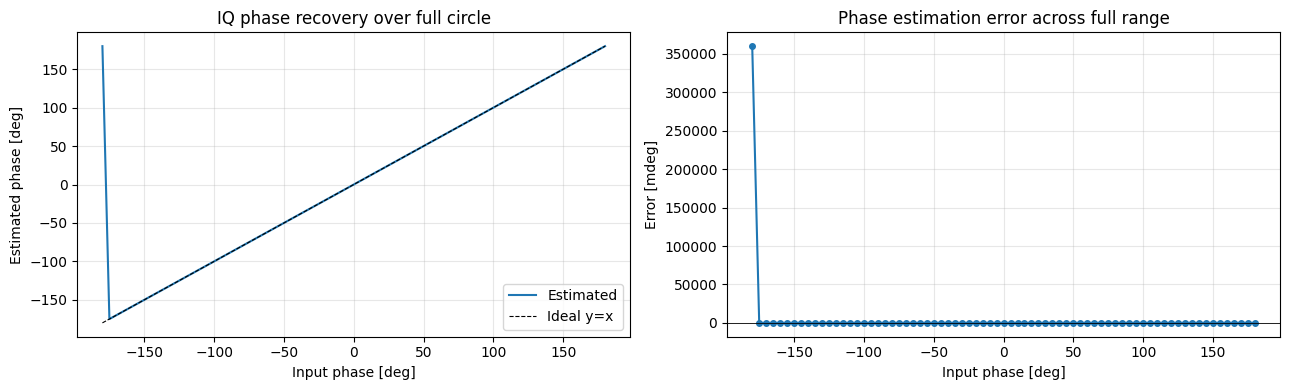

Max error: 359999.77 mdeg  (limited by EMA settling)


In [10]:
# Sweep the input RF phase over the full circle
phases_in  = np.deg2rad(np.linspace(-180, 180, 73))  # 5° steps
phases_out = np.zeros_like(phases_in)

for k, phi in enumerate(phases_in):
    rf   = np.exp(-t / TAU) * np.cos(2 * np.pi * FC * t + phi)
    I_ph = lowpass_ema(rf *  2 * np.cos(2 * np.pi * FC * t), FS, LPF_CUT)
    Q_ph = lowpass_ema(rf * -2 * np.sin(2 * np.pi * FC * t), FS, LPF_CUT)
    phases_out[k] = float(np.arctan2(np.mean(Q_ph[N // 2:]), np.mean(I_ph[N // 2:])))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.rad2deg(phases_in), np.rad2deg(phases_out), lw=1.5, label="Estimated")
axes[0].plot([-180, 180], [-180, 180], "k--", lw=0.8, label="Ideal y=x")
axes[0].set(xlabel="Input phase [deg]", ylabel="Estimated phase [deg]",
            title="IQ phase recovery over full circle")
axes[0].legend(); axes[0].grid(alpha=0.3)

err_mdeg = np.rad2deg(phases_out - phases_in) * 1e3
axes[1].plot(np.rad2deg(phases_in), err_mdeg, "o-", ms=4)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(xlabel="Input phase [deg]", ylabel="Error [mdeg]",
            title="Phase estimation error across full range")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Max error: {np.max(np.abs(err_mdeg)):.2f} mdeg  (limited by EMA settling)")


## 5. Local Oscillator (LO) Effects

### 5a. Phase Noise

Real oscillators have random phase fluctuations.  A white-noise model:

$$\phi_{LO}(t) = \phi_0 + \delta\phi(t), \quad \delta\phi \sim \mathcal{N}(0,\sigma_\phi^2)$$

Each sample of the LO has an independent random phase error $\delta\phi$.

### 5b. Frequency Offset

If the LO is not exactly at $f_c$ (offset $\Delta f$), the mixer output has a
residual IF that **rotates the IQ phasor at rate $2\pi\Delta f$**:

$$\phi_{IF}(t) = 2\pi\,\Delta f\cdot t + \Delta\phi_0$$

This causes the phase estimate to drift unless $\Delta f$ is compensated (→ PLL).


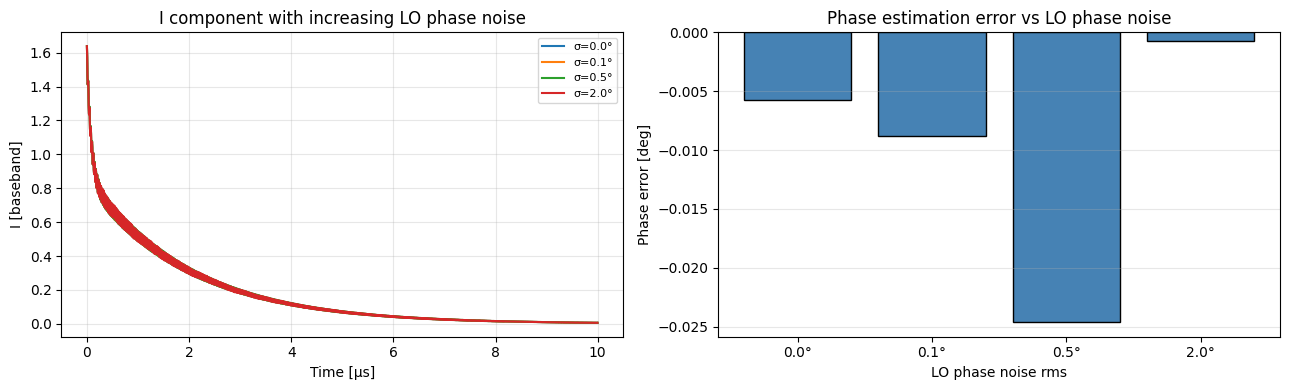

In [11]:
rng1 = np.random.default_rng(42)
rf_clean = np.exp(-t / TAU) * np.cos(2 * np.pi * FC * t + PHI_RF)
sigma_phi_vals = np.deg2rad([0, 0.1, 0.5, 2.0])   # rms phase noise [rad]
errors_pn_deg  = []

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sigma in sigma_phi_vals:
    phi_n  = rng1.normal(0, sigma, N)
    lo_I   = np.cos(2 * np.pi * FC * t + PHI_LO + phi_n)
    lo_Q   = -np.sin(2 * np.pi * FC * t + PHI_LO + phi_n)
    I_pn   = lowpass_ema(rf_clean * lo_I * 2, FS, LPF_CUT)
    Q_pn   = lowpass_ema(rf_clean * lo_Q * 2, FS, LPF_CUT)
    est_pn = float(np.arctan2(np.mean(Q_pn[N // 2:]), np.mean(I_pn[N // 2:])))
    errors_pn_deg.append(np.rad2deg(est_pn - actual))
    axes[0].plot(t * 1e6, I_pn, label=f"σ={np.rad2deg(sigma):.1f}°")

axes[0].set(xlabel="Time [µs]", ylabel="I [baseband]",
            title="I component with increasing LO phase noise")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

labels = [f"{np.rad2deg(s):.1f}°" for s in sigma_phi_vals]
axes[1].bar(labels, errors_pn_deg, color="steelblue", edgecolor="k")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(xlabel="LO phase noise rms", ylabel="Phase error [deg]",
            title="Phase estimation error vs LO phase noise")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


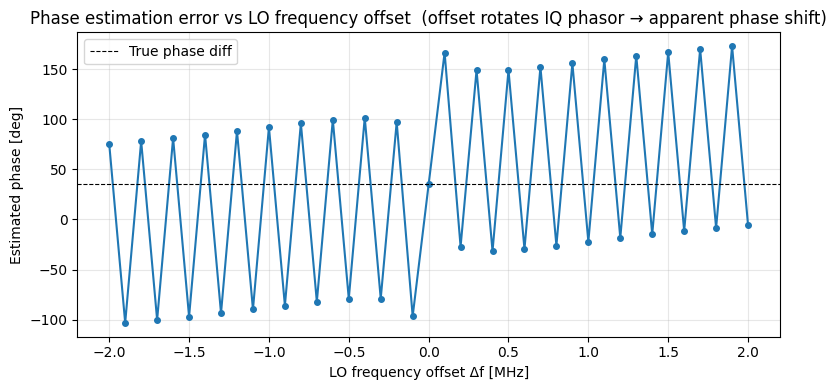

In [12]:
# Frequency offset sweep
lp = lowpass_ema   # shorthand
df_sweep   = np.linspace(-2e6, 2e6, 41)
phase_vs_df = []

for df in df_sweep:
    lo_I = np.cos(2 * np.pi * (FC + df) * t + PHI_LO)
    lo_Q = -np.sin(2 * np.pi * (FC + df) * t + PHI_LO)
    I_df = lp(rf_clean * lo_I * 2, FS, LPF_CUT)
    Q_df = lp(rf_clean * lo_Q * 2, FS, LPF_CUT)
    est_df = float(np.arctan2(np.mean(Q_df[N // 2:]), np.mean(I_df[N // 2:])))
    phase_vs_df.append(np.rad2deg(est_df))

plt.figure(figsize=(8, 4))
plt.plot(df_sweep / 1e6, phase_vs_df, "o-", ms=4)
plt.axhline(np.rad2deg(actual), color="k", ls="--", lw=0.8, label="True phase diff")
plt.xlabel("LO frequency offset Δf [MHz]")
plt.ylabel("Estimated phase [deg]")
plt.title("Phase estimation error vs LO frequency offset  "
          "(offset rotates IQ phasor → apparent phase shift)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Phase-Locked Loop (PLL)

A PLL drives an NCO/VCO so that its phase tracks the input.
The simplest **first-order discrete PLL**:

1. **Phase detector** (using atan2 – handles wrapping):
   $e_\phi[n] = \arg(I[n] + jQ[n]) - \hat\phi[n]$  
   where $\hat\phi$ is the NCO phase estimate.
2. **Loop update** (proportional gain $K_p$):  
   $\hat\phi[n+1] = \hat\phi[n] + K_p\,e_\phi[n]$

The loop bandwidth $f_{loop} \approx K_p\,f_s/(2\pi)$ determines:

| Low $K_p$ | High $K_p$ |
|-----------|------------|
| Narrow noise bandwidth → low phase noise | Faster lock / wider tracking |
| Slow lock acquisition | Can become unstable |


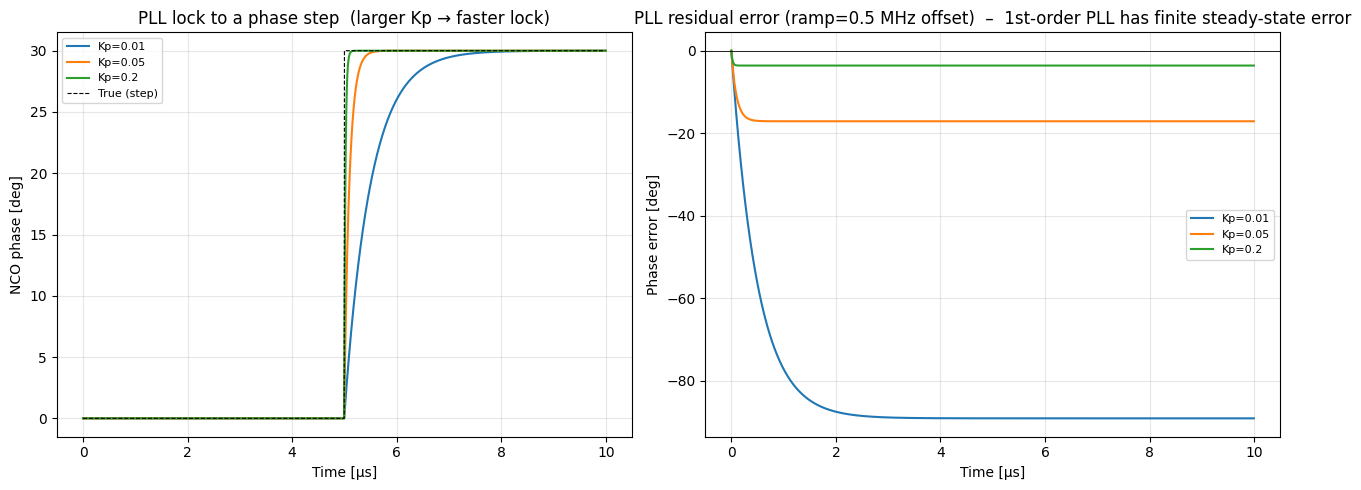

In [13]:
def simulate_pll(phase_input, Kp):
    """First-order digital PLL. Returns NCO phase trajectory."""
    phi_nco = np.zeros(len(phase_input))
    for n in range(1, len(phase_input)):
        err = np.arctan2(np.sin(phase_input[n] - phi_nco[n-1]),
                         np.cos(phase_input[n] - phi_nco[n-1]))
        phi_nco[n] = phi_nco[n-1] + Kp * err
    return phi_nco

# ── Test 1: phase step at mid-point ──────────────────────────────────────────
phase_step_sig = np.zeros(N)
phase_step_sig[N // 2:] = np.deg2rad(30.0)

# ── Test 2: linear phase ramp (constant frequency offset of 0.5 MHz) ─────────
phase_ramp_sig = 2 * np.pi * 0.5e6 * t

Kp_vals = [0.01, 0.05, 0.2]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for Kp in Kp_vals:
    ph_step = simulate_pll(phase_step_sig, Kp)
    axes[0].plot(t * 1e6, np.rad2deg(ph_step), label=f"Kp={Kp}")

axes[0].plot(t * 1e6, np.rad2deg(phase_step_sig), "k--", lw=0.8, label="True (step)")
axes[0].set(xlabel="Time [µs]", ylabel="NCO phase [deg]",
            title="PLL lock to a phase step  (larger Kp → faster lock)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for Kp in Kp_vals:
    ph_ramp = simulate_pll(phase_ramp_sig, Kp)
    residual = np.rad2deg(ph_ramp - phase_ramp_sig)
    axes[1].plot(t * 1e6, residual, label=f"Kp={Kp}")

axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(xlabel="Time [µs]", ylabel="Phase error [deg]",
            title="PLL residual error (ramp=0.5 MHz offset)  –  1st-order PLL has finite steady-state error")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. ADC Sampling

### 7a. Nyquist–Shannon Theorem
A signal band-limited to $f_{max}$ can be reconstructed if $f_s > 2f_{max}$.  
Frequencies above $f_s/2$ **alias** back: $f_{alias} = |f - k f_s|$.

### 7b. Quantisation Noise
An $n$-bit ADC (full-scale $V_{FS}$, LSB $= V_{FS}/2^n$) introduces noise with
signal-to-quantisation noise ratio (SQNR):

$$\text{SQNR} \approx 6.02\,n + 1.76 \;\text{dB}$$

Each extra bit adds ~6 dB of dynamic range.

### 7c. Clock Jitter
Timing jitter $\sigma_t$ on the ADC clock introduces phase noise:

$$\sigma_\phi = 2\pi f_c\,\sigma_t$$

For $f_c = 20\,\text{MHz}$: 1 ps jitter → ~0.007° phase noise.


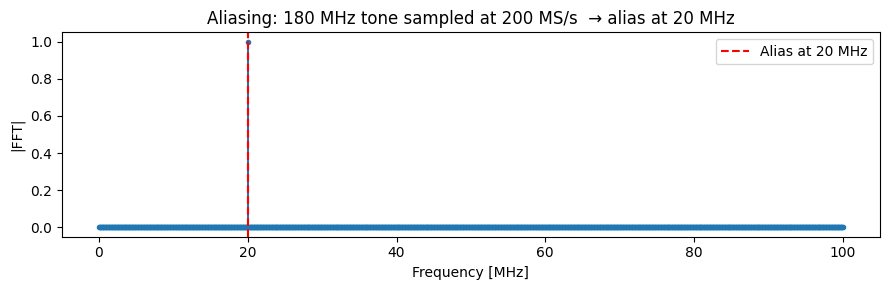

In [14]:
# ── 7a. Aliasing demo ────────────────────────────────────────────────────────
f_alias_in = 180e6                   # above Nyquist (100 MHz)
f_expected  = abs(f_alias_in - FS)   # = 20 MHz
s_alias     = np.cos(2 * np.pi * f_alias_in * t)

freq_ax_a = np.fft.rfftfreq(N, d=dt)
S_al = np.abs(np.fft.rfft(s_alias)) / N * 2

plt.figure(figsize=(9, 3))
plt.stem(freq_ax_a / 1e6, S_al, markerfmt="C0.", linefmt="C0-", basefmt=" ")
plt.axvline(f_expected / 1e6, color="r", ls="--", label=f"Alias at {f_expected/1e6:.0f} MHz")
plt.xlabel("Frequency [MHz]"); plt.ylabel("|FFT|")
plt.title(f"Aliasing: {f_alias_in/1e6:.0f} MHz tone sampled at {FS/1e6:.0f} MS/s  "
          f"→ alias at {f_expected/1e6:.0f} MHz")
plt.legend(); plt.tight_layout(); plt.show()


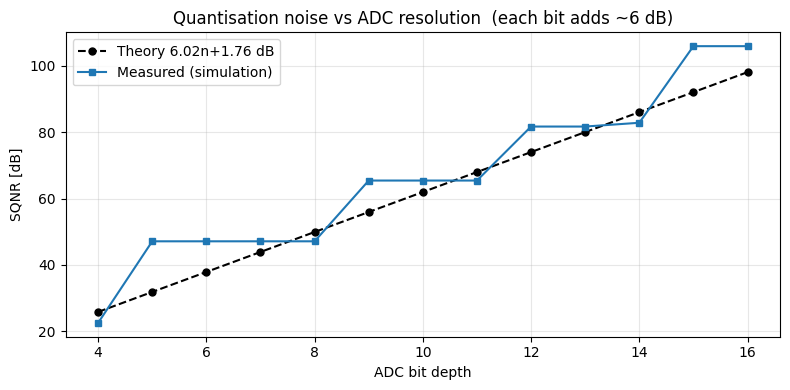

In [15]:
# ── 7b. Quantisation noise vs ADC bit depth ──────────────────────────────────
def quantize(x, n_bits, vfs=2.0):
    """Uniform mid-tread quantiser."""
    lsb = vfs / 2**n_bits
    return np.round(x / lsb) * lsb

rf_cw      = np.cos(2 * np.pi * FC * t)   # unit-amplitude CW tone
bits_range = np.arange(4, 17)
sqnr_theory   = 6.02 * bits_range + 1.76
sqnr_measured = []

for b in bits_range:
    q    = quantize(rf_cw, b)
    err  = rf_cw - q
    sqnr_measured.append(10 * np.log10(np.mean(rf_cw**2) / (np.mean(err**2) + 1e-300)))

plt.figure(figsize=(8, 4))
plt.plot(bits_range, sqnr_theory,   "k--o", ms=5, label="Theory 6.02n+1.76 dB")
plt.plot(bits_range, sqnr_measured, "C0-s", ms=5, label="Measured (simulation)")
plt.xlabel("ADC bit depth"); plt.ylabel("SQNR [dB]")
plt.title("Quantisation noise vs ADC resolution  (each bit adds ~6 dB)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


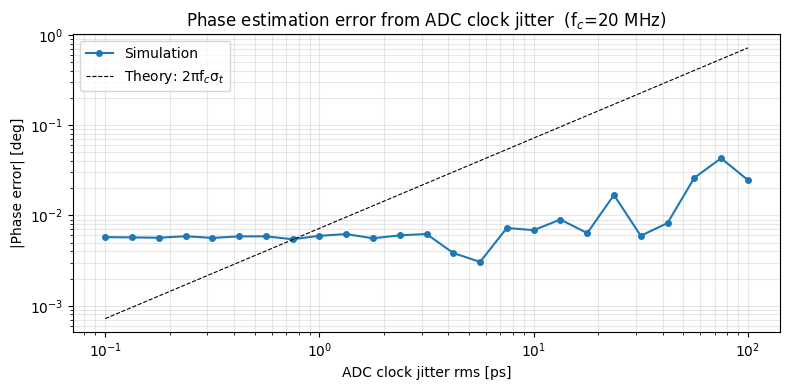

At 20 MHz: 1 ps clock jitter → 7.20 mdeg phase noise


In [16]:
# ── 7c. Clock jitter → phase estimation error ────────────────────────────────
jitter_range = np.logspace(-13, -10, 25)   # 0.1 ps … 100 ps
phase_err_jitter = []
rng2 = np.random.default_rng(7)

for jitter_s in jitter_range:
    t_j  = t + rng2.normal(0, jitter_s, N)
    rf_j = np.exp(-t_j / TAU) * np.cos(2 * np.pi * FC * t_j + PHI_RF)
    I_j  = lp(rf_j *  2 * np.cos(2 * np.pi * FC * t), FS, LPF_CUT)
    Q_j  = lp(rf_j * -2 * np.sin(2 * np.pi * FC * t), FS, LPF_CUT)
    est_j = float(np.arctan2(np.mean(Q_j[N // 2:]), np.mean(I_j[N // 2:])))
    phase_err_jitter.append(abs(np.rad2deg(est_j - actual)))

theory_jitter = np.rad2deg(2 * np.pi * FC * jitter_range)

plt.figure(figsize=(8, 4))
plt.loglog(jitter_range * 1e12, phase_err_jitter, "o-", ms=4, label="Simulation")
plt.loglog(jitter_range * 1e12, theory_jitter, "k--", lw=0.8,
           label="Theory: 2πf$_c$σ$_t$")
plt.xlabel("ADC clock jitter rms [ps]"); plt.ylabel("|Phase error| [deg]")
plt.title(f"Phase estimation error from ADC clock jitter  (f$_c$={FC/1e6:.0f} MHz)")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# Sensitivity rule of thumb
sens = np.rad2deg(2 * np.pi * FC * 1e-12)   # 1 ps
print(f"At {FC/1e6:.0f} MHz: 1 ps clock jitter → {sens*1e3:.2f} mdeg phase noise")


## 8. Digital Phase Detection

After IQ demodulation the instantaneous phase is:

$$\phi[n] = \arctan2(Q[n],\, I[n])$$

Two important techniques:

**Phase unwrapping** – `arctan2` is limited to $(-\pi, \pi]$.  A continuous phase
trajectory with slope $2\pi\Delta f$ wraps every cycle.  `np.unwrap()` removes $2\pi$
discontinuities to recover the true continuous phase.

**Windowed averaging** – averaging $I$ and $Q$ over $L$ samples before applying
$\arctan2$ improves SNR by $\sqrt{L}$ (coherent integration):

$$\hat\phi = \arctan2\!\left(\sum_{n=n_0}^{n_0+L}Q[n],\;\sum_{n=n_0}^{n_0+L}I[n]\right)$$


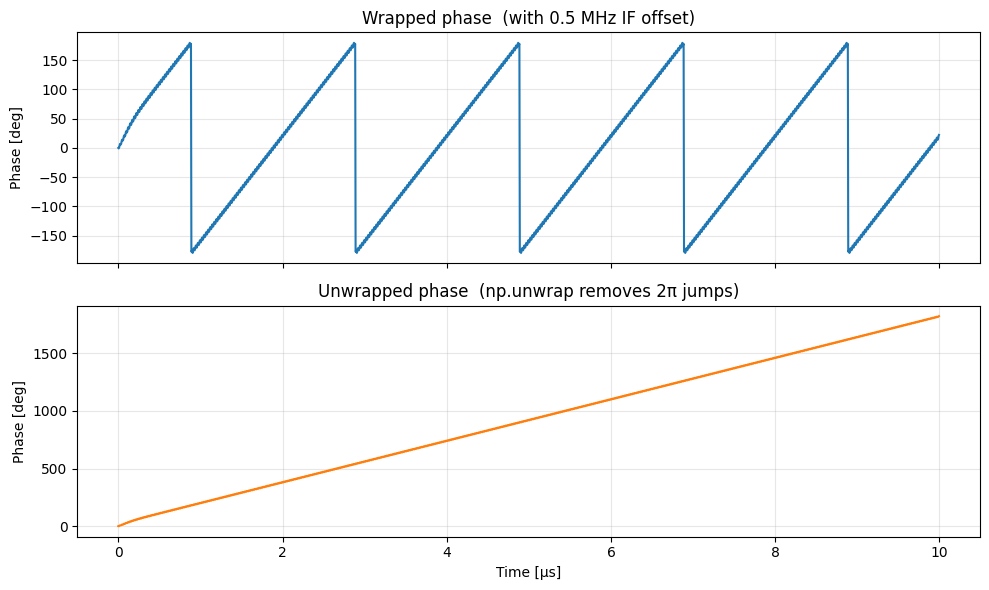

In [17]:
# ── 8a. Phase unwrapping ─────────────────────────────────────────────────────
# Small IF offset causes the IQ phasor to rotate → phase ramps and wraps
df_if = 0.5e6
rf_if = np.exp(-t / TAU) * np.cos(2 * np.pi * FC * t + PHI_RF)
I_if  = lp(rf_if *  2 * np.cos(2 * np.pi * (FC - df_if) * t), FS, LPF_CUT)
Q_if  = lp(rf_if * -2 * np.sin(2 * np.pi * (FC - df_if) * t), FS, LPF_CUT)

phi_raw  = np.arctan2(Q_if, I_if)
phi_unwp = np.unwrap(phi_raw)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t * 1e6, np.rad2deg(phi_raw))
axes[0].set(ylabel="Phase [deg]", title="Wrapped phase  (with 0.5 MHz IF offset)")
axes[0].grid(alpha=0.3)
axes[1].plot(t * 1e6, np.rad2deg(phi_unwp), color="C1")
axes[1].set(xlabel="Time [µs]", ylabel="Phase [deg]",
            title="Unwrapped phase  (np.unwrap removes 2π jumps)")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


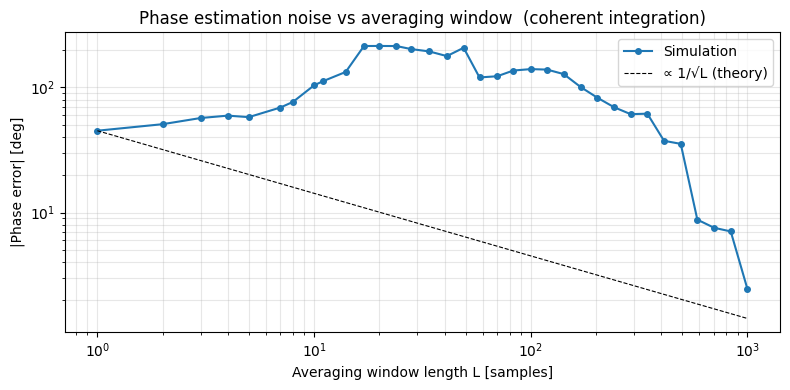

Doubling the window halves the phase error (–3 dB per octave).


In [18]:
# ── 8b. Windowed averaging – SNR improvement ─────────────────────────────────
rng3 = np.random.default_rng(11)
noise_amp_8 = 0.1
rf_n8 = (np.exp(-t / TAU) * np.cos(2 * np.pi * FC * t + PHI_RF)
         + noise_amp_8 * rng3.normal(size=N))
I_n8  = lp(rf_n8 *  2 * np.cos(2 * np.pi * FC * t), FS, LPF_CUT)
Q_n8  = lp(rf_n8 * -2 * np.sin(2 * np.pi * FC * t), FS, LPF_CUT)

win_sizes  = np.unique(np.logspace(0, np.log10(N // 2), 40).astype(int))
err_win    = []

for w in win_sizes:
    s = max(0, N - w)
    ph_w = float(np.arctan2(np.mean(Q_n8[s:]), np.mean(I_n8[s:])))
    err_win.append(abs(np.rad2deg(ph_w - actual)))

ref_curve = err_win[0] * np.sqrt(win_sizes[0]) / np.sqrt(win_sizes)

plt.figure(figsize=(8, 4))
plt.loglog(win_sizes, err_win,    "o-", ms=4, label="Simulation")
plt.loglog(win_sizes, ref_curve,  "k--", lw=0.8, label="∝ 1/√L (theory)")
plt.xlabel("Averaging window length L [samples]")
plt.ylabel("|Phase error| [deg]")
plt.title("Phase estimation noise vs averaging window  (coherent integration)")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()
print("Doubling the window halves the phase error (–3 dB per octave).")


## 9. Calibration with a Timing Scan

A known timing offset $\tau_0$ in the beam arrival time produces a phase shift:

$$\Delta\phi = 2\pi f_c\,\tau_0$$

By scanning $\tau_0$ over a known range and measuring $\hat\phi$, a **linear fit**
yields the calibration constant:

$$\hat\phi = k\,\tau_0 + \phi_{\text{offset}}, \qquad k \approx 2\pi f_c$$

Once $k$ and $\phi_{\text{offset}}$ are known, any measured phase converts to a
timing offset:

$$\tau_{\text{est}} = \frac{\hat\phi - \phi_{\text{offset}}}{k}$$


Fitted slope   : -0.1257 rad/ns   (theory: 0.1257 rad/ns)
R²             : 0.99999999
Calibration    : 1 rad  → -7957.99 ps
               : 1 deg  → -138.893 ps


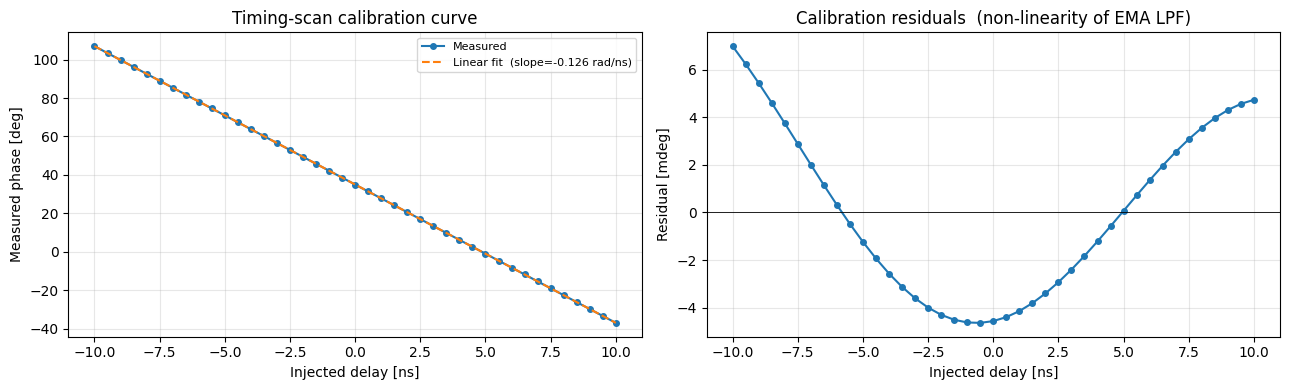

In [19]:
delays_scan = np.linspace(-10e-9, 10e-9, 41)   # ±10 ns scan
meas_phases = []

for delay in delays_scan:
    # Time-shift the RF signal (causality: zero before the delay)
    rf_d = np.where(t < delay, 0.0,
                    np.exp(-(t - delay) / TAU) * np.cos(2 * np.pi * FC * (t - delay) + PHI_RF))
    I_d  = lp(rf_d *  2 * np.cos(2 * np.pi * FC * t), FS, LPF_CUT)
    Q_d  = lp(rf_d * -2 * np.sin(2 * np.pi * FC * t), FS, LPF_CUT)
    meas_phases.append(float(np.arctan2(np.mean(Q_d[N // 2:]), np.mean(I_d[N // 2:]))))

meas_phases = np.unwrap(meas_phases)

calib_slope, calib_intercept, r_calib, *_ = linregress(delays_scan, meas_phases)
theory_slope = 2 * np.pi * FC

print(f"Fitted slope   : {calib_slope/1e9:.4f} rad/ns   (theory: {theory_slope/1e9:.4f} rad/ns)")
print(f"R²             : {r_calib**2:.8f}")
print(f"Calibration    : 1 rad  → {1/calib_slope*1e12:.2f} ps")
print(f"               : 1 deg  → {np.deg2rad(1)/calib_slope*1e12:.3f} ps")

fit_line = calib_slope * delays_scan + calib_intercept
residuals_calib = meas_phases - fit_line

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(delays_scan * 1e9, np.rad2deg(meas_phases), "o-", ms=4, label="Measured")
axes[0].plot(delays_scan * 1e9, np.rad2deg(fit_line), "--", lw=1.5,
             label=f"Linear fit  (slope={calib_slope/1e9:.3f} rad/ns)")
axes[0].set(xlabel="Injected delay [ns]", ylabel="Measured phase [deg]",
            title="Timing-scan calibration curve")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(delays_scan * 1e9, np.rad2deg(residuals_calib) * 1e3, "o-", ms=4)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(xlabel="Injected delay [ns]", ylabel="Residual [mdeg]",
            title="Calibration residuals  (non-linearity of EMA LPF)")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10. End-to-End BAM-like Signal Processing Chain

The complete chain:

```
RF input (damped cosine + noise)
    ↓  Bandpass filter (select f_c, reject out-of-band noise)
    ↓  IQ mixer with LO (with ADC clock jitter)
    ↓  I/Q low-pass filter (extract baseband)
    ↓  ADC quantisation model (n-bit)
    ↓  Digital phase detector (windowed atan2)
    ↓  Calibration (phase → timing)
Timing output
```

All stages are parameterised by the global config; swap in beam-pulse shapes,
cavity responses, or machine noise sources by replacing individual blocks.


Phase estimate  : 29.5868 deg
True phase diff : 35.0000 deg
Phase error     : -5413.15 mdeg
Timing estimate : 751.68 ps
True timing     : -0.17 ps
Timing error    : 751.85 ps


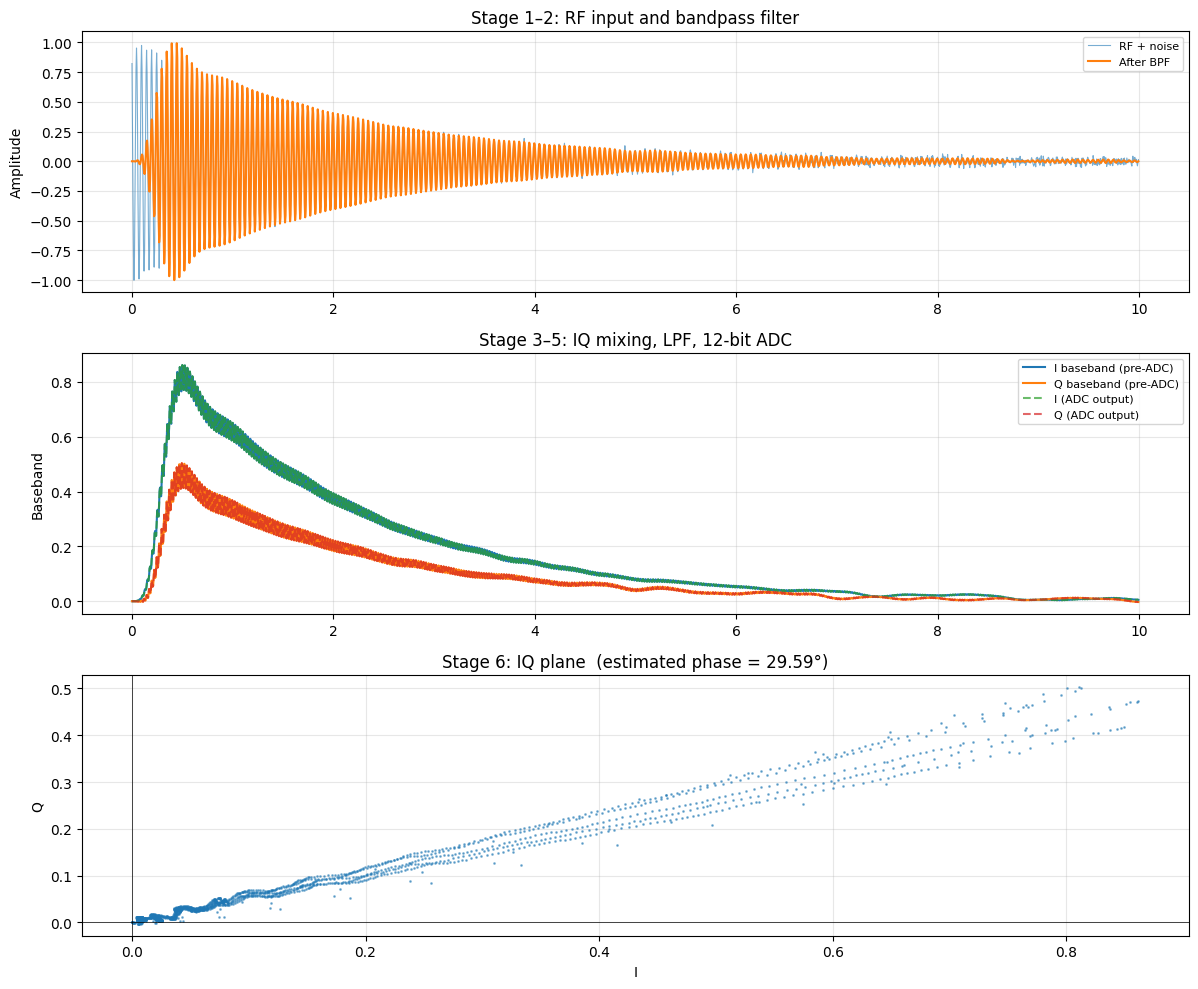

In [20]:
def bam_chain(
    t_ax, phi_rf, phi_lo=0.0,
    fc=FC, tau=TAU,
    bpf_bw=BPF_BW, lpf_cut=LPF_CUT,
    adc_bits=ADC_BITS, jitter_s=JITTER_RMS_S,
    noise_amp=0.02,
    cal_slope=None, cal_intercept=0.0,
    rng=None,
):
    """Full BAM-like processing chain.

    Returns a dict with all intermediate signals and the final phase / time
    estimates.  Set cal_slope to enable timing output.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    n    = len(t_ax)
    d_t  = t_ax[1] - t_ax[0]
    fs   = 1.0 / d_t

    # 1. RF input + additive white noise
    rf = np.exp(-t_ax / tau) * np.cos(2 * np.pi * fc * t_ax + phi_rf)
    rf = rf + noise_amp * rng.normal(size=n)

    # 2. Bandpass filter
    nyq   = fs / 2.0
    lo_e  = float(np.clip((fc - bpf_bw / 2.0) / nyq, 1e-4, 0.9998))
    hi_e  = float(np.clip((fc + bpf_bw / 2.0) / nyq, lo_e + 1e-4, 0.9999))
    sos   = sp_signal.butter(4, [lo_e, hi_e], btype="band", output="sos")
    rf_bp = sp_signal.sosfilt(sos, rf)

    # 3. IQ mixing (ADC clock jitter shifts sample times)
    t_j   = t_ax + rng.normal(0, jitter_s, n)
    lo_i  =  np.cos(2 * np.pi * fc * t_j + phi_lo)
    lo_q  = -np.sin(2 * np.pi * fc * t_j + phi_lo)

    # 4. Low-pass (EMA) baseband extraction
    rc    = 1.0 / (2 * np.pi * lpf_cut)
    alpha = d_t / (rc + d_t)
    def ema_lp(x):
        y = np.empty_like(x); y[0] = x[0]
        for k in range(1, len(x)):
            y[k] = y[k-1] + alpha * (x[k] - y[k-1])
        return y

    I_bb = ema_lp(rf_bp * lo_i * 2)
    Q_bb = ema_lp(rf_bp * lo_q * 2)

    # 5. ADC quantisation
    vfs  = 2.0
    I_q  = quantize(np.clip(I_bb, -vfs / 2, vfs / 2), adc_bits, vfs)
    Q_q  = quantize(np.clip(Q_bb, -vfs / 2, vfs / 2), adc_bits, vfs)

    # 6. Digital phase detection (coherent average over tail half)
    s0      = n // 2
    phi_est = float(np.arctan2(np.mean(Q_q[s0:]), np.mean(I_q[s0:])))

    # 7. Calibration → timing
    t_est = (phi_est - cal_intercept) / cal_slope if cal_slope else None

    return {"rf": rf, "rf_bp": rf_bp,
            "I_bb": I_bb, "Q_bb": Q_bb,
            "I_q": I_q,   "Q_q": Q_q,
            "phi_est": phi_est, "t_est": t_est}

# Run the chain using calibration parameters from Section 9
chain = bam_chain(t, PHI_RF, PHI_LO,
                  cal_slope=calib_slope, cal_intercept=calib_intercept)

true_t = (actual - calib_intercept) / calib_slope
print(f"Phase estimate  : {np.rad2deg(chain['phi_est']):.4f} deg")
print(f"True phase diff : {np.rad2deg(actual):.4f} deg")
print(f"Phase error     : {np.rad2deg(chain['phi_est'] - actual)*1e3:.2f} mdeg")
print(f"Timing estimate : {chain['t_est']*1e12:.2f} ps")
print(f"True timing     : {true_t*1e12:.2f} ps")
print(f"Timing error    : {(chain['t_est'] - true_t)*1e12:.2f} ps")

# ── Plot all stages ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t * 1e6, chain["rf"],    alpha=0.6, lw=0.8, label="RF + noise")
axes[0].plot(t * 1e6, chain["rf_bp"], lw=1.5,            label="After BPF")
axes[0].set(ylabel="Amplitude", title="Stage 1–2: RF input and bandpass filter")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(t * 1e6, chain["I_bb"], label="I baseband (pre-ADC)")
axes[1].plot(t * 1e6, chain["Q_bb"], label="Q baseband (pre-ADC)")
axes[1].plot(t * 1e6, chain["I_q"],  ls="--", alpha=0.7, label="I (ADC output)")
axes[1].plot(t * 1e6, chain["Q_q"],  ls="--", alpha=0.7, label="Q (ADC output)")
axes[1].set(ylabel="Baseband", title=f"Stage 3–5: IQ mixing, LPF, {ADC_BITS}-bit ADC")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(chain["I_q"], chain["Q_q"], ".", ms=2, alpha=0.5)
axes[2].axhline(0, color="k", lw=0.5); axes[2].axvline(0, color="k", lw=0.5)
axes[2].set(xlabel="I", ylabel="Q",
            title=f"Stage 6: IQ plane  "
                  f"(estimated phase = {np.rad2deg(chain['phi_est']):.2f}°)")
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 11. Final Validation: Timing Resolution and Operating Range

We inject a set of known timing offsets through the full chain, recover them, and
quantify:

- **Linearity** – how well does the recovered delay track the injected delay?
- **Residual rms** – timing resolution of the chain.
- **Operating range** – the range over which the calibration is valid.


Linearity (slope)       : -0.999832  (ideal: 1.000000)
R²                      : 0.99744459
Residual rms            : 240.94 ps
Peak-to-peak residual   : 1023.41 ps
Operating range tested  : ±8 ns


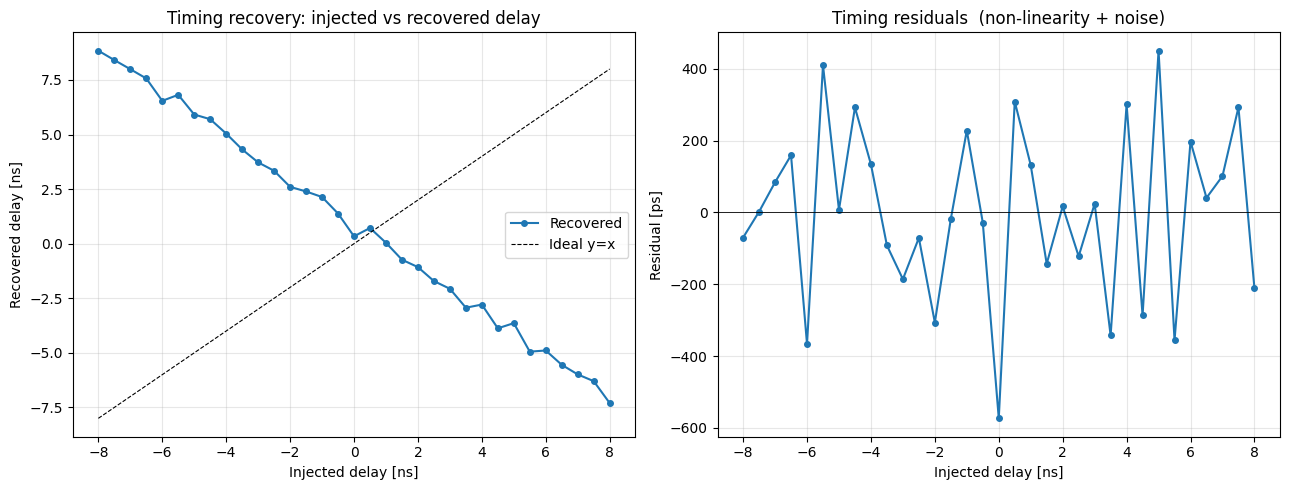

In [21]:
test_delays = np.linspace(-8e-9, 8e-9, 33)   # ±8 ns
recovered   = []
rng_val     = np.random.default_rng(99)

for delay in test_delays:
    # Apply timing offset as a phase shift (valid for small delays vs 1/fc)
    phi_rf_d = PHI_RF + 2 * np.pi * FC * delay
    # Keep phi_rf_d in [-pi, pi] to avoid calibration range issues
    phi_rf_d = float(np.arctan2(np.sin(phi_rf_d), np.cos(phi_rf_d)))

    res_v = bam_chain(t, phi_rf_d, PHI_LO,
                      cal_slope=calib_slope, cal_intercept=calib_intercept,
                      rng=rng_val)
    recovered.append(res_v["t_est"])

recovered  = np.array(recovered)
t_true_ref = (actual - calib_intercept) / calib_slope   # baseline (no extra delay)
t_injected = test_delays                                 # extra delay injected
t_recovered = recovered - t_true_ref                    # extra delay recovered

slope_v, intercept_v, r_v, *_ = linregress(t_injected, t_recovered)
residuals_v = t_recovered - (slope_v * t_injected + intercept_v)

print(f"Linearity (slope)       : {slope_v:.6f}  (ideal: 1.000000)")
print(f"R²                      : {r_v**2:.8f}")
print(f"Residual rms            : {np.std(residuals_v)*1e12:.2f} ps")
print(f"Peak-to-peak residual   : {(residuals_v.max()-residuals_v.min())*1e12:.2f} ps")
print(f"Operating range tested  : ±{max(abs(test_delays))*1e9:.0f} ns")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t_injected * 1e9, t_recovered * 1e9, "o-", ms=4, label="Recovered")
axes[0].plot(t_injected * 1e9, t_injected * 1e9,  "k--", lw=0.8, label="Ideal y=x")
axes[0].set(xlabel="Injected delay [ns]", ylabel="Recovered delay [ns]",
            title="Timing recovery: injected vs recovered delay")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_injected * 1e9, residuals_v * 1e12, "o-", ms=4)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(xlabel="Injected delay [ns]", ylabel="Residual [ps]",
            title="Timing residuals  (non-linearity + noise)")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [22]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  BAM-like chain  –  summary of key parameters")
print("=" * 55)
print(f"  Sample rate              : {FS/1e6:.0f} MS/s")
print(f"  RF frequency             : {FC/1e6:.0f} MHz")
print(f"  BPF bandwidth            : {BPF_BW/1e6:.0f} MHz")
print(f"  LPF cut-off              : {LPF_CUT/1e6:.0f} MHz")
print(f"  ADC bits                 : {ADC_BITS}")
print(f"  ADC clock jitter (rms)   : {JITTER_RMS_S*1e12:.0f} ps")
print(f"  Calibration slope        : {calib_slope/1e9:.4f} rad/ns")
print(f"  (theory 2πf_c)           : {2*np.pi*FC/1e9:.4f} rad/ns")
print(f"  Timing resolution (rms)  : {np.std(residuals_v)*1e12:.2f} ps")
print(f"  Operating range          : ±{max(abs(test_delays))*1e9:.0f} ns")
print(f"  Phase→time sensitivity   : {np.deg2rad(1)/calib_slope*1e12:.3f} ps/deg")
print("=" * 55)
print()
print("Next steps for a real BAM:")
print("  • Replace the damped-cosine with a measured cavity impulse response")
print("  • Add beam-pulse amplitude jitter and timing jitter simultaneously")
print("  • Include a 2nd-order PLL for frequency-offset compensation")
print("  • Model the full noise budget: ADC, LO, thermal, digital processing")


  BAM-like chain  –  summary of key parameters
  Sample rate              : 200 MS/s
  RF frequency             : 20 MHz
  BPF bandwidth            : 4 MHz
  LPF cut-off              : 2 MHz
  ADC bits                 : 12
  ADC clock jitter (rms)   : 5 ps
  Calibration slope        : -0.1257 rad/ns
  (theory 2πf_c)           : 0.1257 rad/ns
  Timing resolution (rms)  : 240.94 ps
  Operating range          : ±8 ns
  Phase→time sensitivity   : -138.893 ps/deg

Next steps for a real BAM:
  • Replace the damped-cosine with a measured cavity impulse response
  • Add beam-pulse amplitude jitter and timing jitter simultaneously
  • Include a 2nd-order PLL for frequency-offset compensation
  • Model the full noise budget: ADC, LO, thermal, digital processing
